# Crop Yield Optimization

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
crop_yield_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Crop_Yield_Optimization/Dataset/crop_yield.csv')

## First 5 entries of dataset

In [66]:
crop_yield_data.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


## Statistical Summary

In [67]:
crop_yield_data.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


## Flow of the project
* Cleaning the Dataset
  * Drop the year column
  * Drop Whole year row
* One hot encode season and state (NEWS)
* Inputs
  * Area
  * Rainfall
  * Fertilizer
  * Seasons (One-hot encoded)
  * States (One-hot encoded)
* Outputs
  * Production
  * Pesticide

* Trade-offs
  * Maximize Production, Minimize Pesticide

* Train-test and validation split
* Normalization
* Model training
* Metrics

* Optimization using NSGA 3
* Pareto Chart


In [68]:
crop_yield_data.columns

Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield'],
      dtype='object')

## Filtering the data for rice only

In [69]:
rice_df = crop_yield_data[crop_yield_data['Crop'].str.strip() == 'Rice'].copy()

In [70]:
# Saving the rice-specific data to a new file
rice_df.to_csv('rice_yield_data.csv', index=False)

In [71]:
print(f"Total records for Rice: {len(rice_df)}")

Total records for Rice: 1197


In [72]:
rice_df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
16,Rice,1997,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870
17,Rice,1997,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435
18,Rice,1997,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304
51,Rice,1997,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500
52,Rice,1997,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846


In [73]:
rice_df['Production'].mean()

np.float64(1862407.000835422)

In [74]:
rice_df['Pesticide'].mean()

np.float64(223779.96655480372)

## Dropping the year column

In [75]:
rice_df = rice_df.drop(columns='Crop_Year')
rice_df.head()

,Crop,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
16,Rice,Autumn,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870
17,Rice,Summer,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435
18,Rice,Winter,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304
51,Rice,Kharif,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500
52,Rice,Rabi,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846


In [76]:
rice_df.shape

(1197, 9)

## Listing all the categorical variables

In [77]:
categorical_cols = rice_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)

['Crop', 'Season', 'State']


## Identifying categories within specified column

### Season

In [78]:
# Getting unique categories (with stripping to remove extra spaces)
unique_seasons = rice_df['Season'].str.strip().unique()

# Seeing how many times each season appears
season_counts = rice_df['Season'].str.strip().value_counts()

print("Unique Seasons:")
print(unique_seasons)

print("\nNumber of records per season:")
print(season_counts)

Unique Seasons:
['Autumn' 'Summer' 'Winter' 'Kharif' 'Rabi' 'Whole Year']

Number of records per season:
Season
Kharif        505
Summer        244
Autumn        158
Winter        147
Rabi          139
Whole Year      4
Name: count, dtype: int64


#### Removing the Whole Year rows

In [79]:
rice_df = rice_df[~rice_df['Season'].str.contains('Whole', case=False, na=False)].copy()

rice_df.shape

(1193, 9)

## One hot Encoding

### Seasons

In [80]:
rice_df = pd.get_dummies(rice_df, columns=['Season'], prefix='Season')

In [81]:
rice_df.columns

Index(['Crop', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer',
       'Pesticide', 'Yield', 'Season_Autumn     ', 'Season_Kharif     ',
       'Season_Rabi       ', 'Season_Summer     ', 'Season_Winter     '],
      dtype='object')

In [82]:
rice_df.head()

,Crop,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Season_Autumn,Season_Kharif,Season_Rabi,Season_Summer,Season_Winter
16,Rice,Assam,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,True,False,False,False,False
17,Rice,Assam,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,False,False,False,True,False
18,Rice,Assam,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,False,False,False,False,True
51,Rice,Karnataka,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,False,True,False,False,False
52,Rice,Karnataka,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,False,False,True,False,False


### States
* North
* South
* NorthEast
* Central

In [83]:
# Defining the mapping of states to the four regions
state_to_region = {
    'Punjab': 'North', 'Uttar Pradesh': 'North', 'Haryana': 'North', 'Himachal Pradesh': 'North',
    'Madhya Pradesh': 'Central', 'Uttarakhand': 'North', 'Delhi': 'North', 'Jammu and Kashmir': 'North',
    'Assam': 'NorthEast', 'West Bengal': 'North', 'Bihar': 'North', 'Tripura': 'NorthEast', 'Nagaland': 'NorthEast',
    'Odisha': 'Central', 'Chhattisgarh': 'Central', 'Mizoram': 'NorthEast', 'Jharkhand': 'North', 'Manipur': 'NorthEast',
    'Arunachal Pradesh': 'NorthEast', 'Sikkim': 'North', 'Meghalaya': 'NorthEast', 'Karnataka': 'South', 'Kerala': 'South', 'Andhra Pradesh': 'South', 'Tamil Nadu': 'South',
    'Telangana': 'South', 'Puducherry': 'South', 'Maharashtra': 'South', 'Gujarat': 'Central', 'Goa': 'South'
}

In [84]:
# Creating a temporary 'Region' column based on the mapping
rice_df['Region'] = rice_df['State'].map(state_to_region)

In [85]:
# One-hot encoding the 'Region' column and drop the original 'State' and 'Region' columns
rice_df = pd.get_dummies(rice_df, columns=['Region'], prefix='Region')
rice_df = rice_df.drop('State', axis=1)

In [86]:
rice_df.head()

,Crop,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Season_Autumn,Season_Kharif,Season_Rabi,Season_Summer,Season_Winter,Region_Central,Region_North,Region_NorthEast,Region_South
16,Rice,607358.0,398311,2051.4,5.780226e+07,188280.98,0.780870,True,False,False,False,False,False,False,True,False
17,Rice,174974.0,209623,2051.4,1.665228e+07,54241.94,1.060435,False,False,False,True,False,False,False,True,False
18,Rice,1743321.0,1647296,2051.4,1.659119e+08,540429.51,0.941304,False,False,False,False,True,False,False,True,False
51,Rice,1031530.0,2340493,1266.7,9.817071e+07,319774.30,2.233500,False,True,False,False,False,False,False,False,True
52,Rice,53889.0,109350,1266.7,5.128616e+06,16705.59,2.073846,False,False,True,False,False,False,False,False,True


In [87]:
rice_df.columns

Index(['Crop', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer',
       'Pesticide', 'Yield', 'Season_Autumn     ', 'Season_Kharif     ',
       'Season_Rabi       ', 'Season_Summer     ', 'Season_Winter     ',
       'Region_Central', 'Region_North', 'Region_NorthEast', 'Region_South'],
      dtype='object')

## Splitting the Data

In [88]:
from sklearn.model_selection import train_test_split

In [89]:
input_cols = ['Area', 'Annual_Rainfall', 'Fertilizer',
              'Season_Autumn     ', 'Season_Kharif     ', 'Season_Rabi       ', 'Season_Summer     ', 'Season_Winter     ',
              'Region_Central', 'Region_North', 'Region_NorthEast', 'Region_South']

output_cols = ['Production', 'Pesticide']

In [90]:
# Extracting the values
X = rice_df[input_cols].values
y = rice_df[output_cols].values

In [91]:
# First split: 70% Training, 30% for the rest (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

In [92]:
# Second split: Divide the remaining 30% into two equal parts (15% Validation, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

## Normalizing the Input and Output data

In [93]:
from sklearn.preprocessing import StandardScaler

In [94]:
# Initializing the Scalers
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [95]:
# Fitting only on the Training set
X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

# Transforming the Validation and Test sets using the parameters from the Training set
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

In [96]:
# Training data shape (70%)
print(f"X_train shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train_scaled.shape}")

X_train shape: (835, 12)
y_train shape: (835, 2)


In [97]:
# Testing data shape (15%)
print(f"X_test shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test_scaled.shape}")

X_test shape: (179, 12)
y_test shape: (179, 2)


In [98]:
# Validation data shape (15%)
print(f"X_val shape: {X_val_scaled.shape}")
print(f"y_val shape: {y_val_scaled.shape}")

X_val shape: (179, 12)
y_val shape: (179, 2)


In [99]:
# Converting back to a DataFrame to see the results
X_refined_df = pd.DataFrame(X_train_scaled, columns=input_cols)
y_refined_df = pd.DataFrame(y_train_scaled, columns=output_cols)

In [100]:
X_refined_df.head()

,Area,Annual_Rainfall,Fertilizer,Season_Autumn,Season_Kharif,Season_Rabi,Season_Summer,Season_Winter,Region_Central,Region_North,Region_NorthEast,Region_South
0,-0.520342,0.063353,-0.543257,-0.399653,1.174273,-0.368856,-0.496255,-0.377188,-0.366757,-0.695073,1.666817,-0.640682
1,-0.455260,-0.525197,-0.406811,-0.399653,1.174273,-0.368856,-0.496255,-0.377188,-0.366757,-0.695073,1.666817,-0.640682
2,-0.634014,0.812108,-0.615437,-0.399653,1.174273,-0.368856,-0.496255,-0.377188,-0.366757,-0.695073,1.666817,-0.640682
3,-0.608796,1.358206,-0.601717,-0.399653,-0.851591,-0.368856,2.015095,-0.377188,-0.366757,-0.695073,-0.599946,1.560838
4,-0.613532,-0.264182,-0.599531,-0.399653,-0.851591,-0.368856,2.015095,-0.377188,-0.366757,-0.695073,-0.599946,1.560838


In [101]:
y_refined_df.head()

,Production,Pesticide
0,-0.507828,-0.500283
1,-0.414166,-0.376411
2,-0.616823,-0.597466
3,-0.588827,-0.576910
4,-0.597231,-0.585580


## Training ANN Model

### One ANN for all outputs

In [102]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [103]:
# Define the ANN Architecture
# We use 3 hidden layers to capture the complexity of the data
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)), # Input Layer
    Dropout(0.1),                                                         # Prevents overfitting
    Dense(64, activation='relu'),                                        # Hidden Layer 2
    Dense(32, activation='relu'),                                        # Hidden Layer 3
    Dense(2)
])

In [104]:
# Compile the model
# Adam optimizer is great for regression; MSE is the standard loss for continuous values
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [105]:
# Early Stopping: Stops training if the validation loss stops improving
# This ensures we don't overfit to the training set
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [106]:
# Train the model
# We feed the training data and validate against the validation data
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.4750 - mae: 0.4337 - val_loss: 0.1607 - val_mae: 0.2559
Epoch 2/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1301 - mae: 0.2147 - val_loss: 0.1002 - val_mae: 0.1763
Epoch 3/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0961 - mae: 0.1765 - val_loss: 0.0916 - val_mae: 0.1660
Epoch 4/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0912 - mae: 0.1707 - val_loss: 0.0822 - val_mae: 0.1582
Epoch 5/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0806 - mae: 0.1640 - val_loss: 0.0803 - val_mae: 0.1559
Epoch 6/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0776 - mae: 0.1568 - val_loss: 0.0915 - val_mae: 0.1654
Epoch 7/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0781 - mae: 0.1590 - val_loss: 0.0812 - val_mae: 0.1524
Epoch 8/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0698 - mae: 0.1470 - val_loss: 0.0744 - val_mae: 0.1460
Epoch 9/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.07

### Metrics

In [107]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# Generating predictions for all sets
train_preds = model.predict(X_train_scaled)
val_preds = model.predict(X_val_scaled)
test_preds = model.predict(X_test_scaled)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [108]:
# Function to print scores for both outputs
def get_metrics(y_true, y_pred, set_name):
    metrics = []
    targets = ['Production', 'Pesticide']

    for i, target in enumerate(targets):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true[:, i], y_pred[:, i])

        metrics.append({
            'Dataset': set_name,
            'Target': target,
            'MSE': mse,
            'RMSE': rmse,
            'R2': r2
        })
    return metrics


In [109]:
# Combine results into a DataFrame
all_metrics = []
all_metrics.extend(get_metrics(y_train_scaled, train_preds, 'Training'))
all_metrics.extend(get_metrics(y_val_scaled, val_preds, 'Validation'))
all_metrics.extend(get_metrics(y_test_scaled, test_preds, 'Testing'))

results_df = pd.DataFrame(all_metrics)

In [110]:
# Displaying the table
print("ANN Performance Metrics (Scaled Units):")
results_df

ANN Performance Metrics (Scaled Units):


,Dataset,Target,MSE,RMSE,R2
0,Training,Production,0.036306,0.190542,0.963694
1,Training,Pesticide,0.067495,0.259799,0.932505
2,Validation,Production,0.051156,0.226177,0.963328
3,Validation,Pesticide,0.088160,0.296917,0.942144
4,Testing,Production,0.037307,0.193151,0.971668
5,Testing,Pesticide,0.156790,0.395967,0.855096


In [111]:
import matplotlib.pyplot as plt

def plot_regression(y_true, y_pred, title, color):
    plt.scatter(y_true, y_pred, alpha=0.4, c=color)
    # 45-degree reference line
    line_coords = [y_true.min(), y_true.max()]
    plt.plot(line_coords, line_coords, 'r--', lw=2)
    plt.xlabel('True Values (Scaled)')
    plt.ylabel('Predicted Values (Scaled)')
    plt.title(title)
    plt.grid(True, linestyle=':', alpha=0.6)

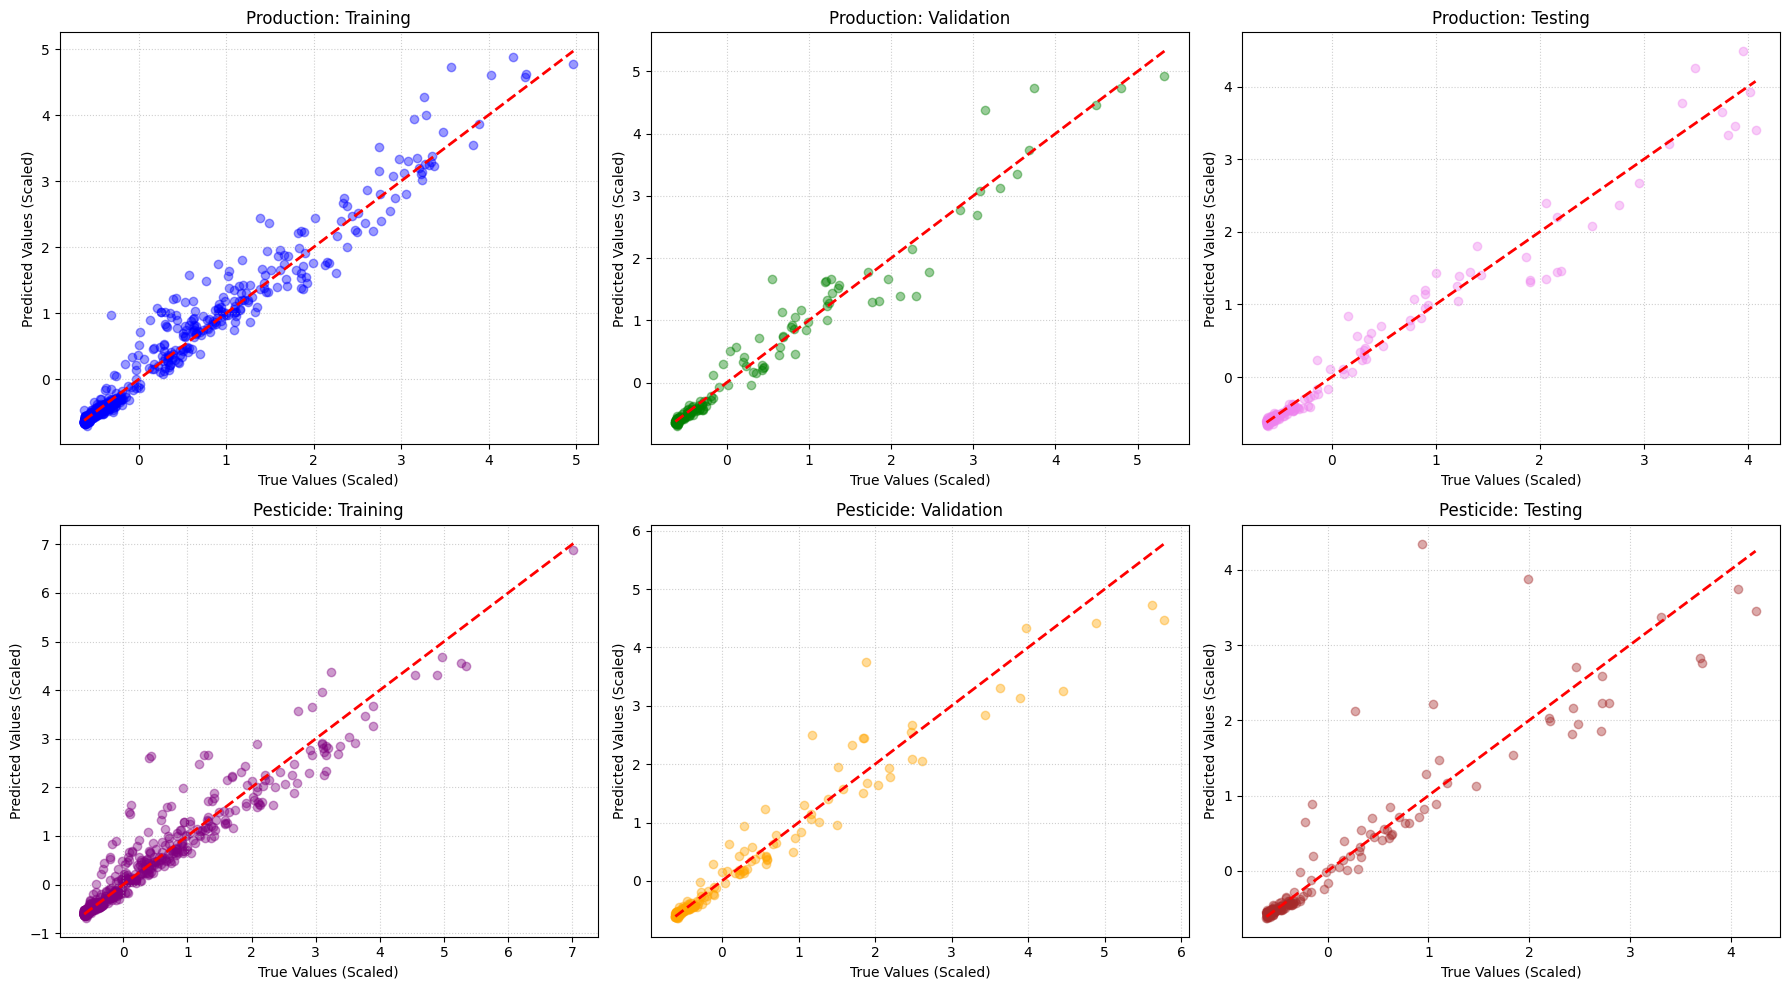

In [112]:
plt.figure(figsize=(18, 10))
# --- PRODUCTION PLOTS ---
plt.subplot(2, 3, 1)
plot_regression(y_train_scaled[:, 0], train_preds[:, 0], "Production: Training", "blue")

plt.subplot(2, 3, 2)
plot_regression(y_val_scaled[:, 0], val_preds[:, 0], "Production: Validation", "green")

plt.subplot(2, 3, 3)
plot_regression(y_test_scaled[:, 0], test_preds[:, 0], "Production: Testing", "violet")

# --- PESTICIDE PLOTS ---
plt.subplot(2, 3, 4)
plot_regression(y_train_scaled[:, 1], train_preds[:, 1], "Pesticide: Training", "purple")

plt.subplot(2, 3, 5)
plot_regression(y_val_scaled[:, 1], val_preds[:, 1], "Pesticide: Validation", "orange")

plt.subplot(2, 3, 6)
plot_regression(y_test_scaled[:, 1], test_preds[:, 1], "Pesticide: Testing", "brown")

plt.tight_layout()
plt.show()

# Defining the Optimization Problem

### Decision Variables (Inputs)
* Area
* Annual_Rainfall
* Fertilizer
* Note: Categorical variables like Season and Region will be kept fixed during one optimization run.

### Objectives (Outputs)
* Maximize Production
* Minimize Pesticide

### Constraints
* Using our trained ANN to calculate the objectives.
* The optimizer will 'guess' an input, feed it in the ANN, see the predicted Production and Pesticide and then further refine the guess.

### Selection of Optimizer
* NSGA-III -> Non Dominated Sorting Genetic Algorithm III
  * Creates a population of random input combinations.
  * Uses ANN to predict outcomes for all of them.
  * Selects the best ones.
  * Evolves them over generations to find the most efficient balance.

### Optimization Code

###  NSGA III

In [113]:
!pip install pymoo

In [114]:
import numpy as np
import pandas as pd
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.optimize import minimize
from pymoo.util.ref_dirs import get_reference_directions

class CropOptimization(Problem):
    def __init__(self, ann_model, fixed_features):
        # n_var=3 (Area, Annual_Rainfall, Fertilizer)
        # n_obj=2 (Production, Pesticide)
        super().__init__(n_var=3, n_obj=2, n_constr=0,
                         # Keep bounds within the range of scaled training data
                         xl=np.array([-0.5, -1.0, -1.0]),
                         xu=np.array([2.5, 2.5, 2.5]))
        self.ann_model = ann_model
        self.fixed_features = fixed_features

    def _evaluate(self, x, out, *args, **kwargs):
        # x contains the population of decision variables (shape: N_population x 3)
        num_samples = x.shape[0]

        # 1. Enforce strict input bounds just in case
        x_clipped = np.clip(x, -2.5, 2.5)

        # 2. Tile the fixed features to match the population size
        # This attaches the specific Season/Region to every guess the optimizer makes
        fixed_batch = np.tile(self.fixed_features, (num_samples, 1))

        # 3. Concatenate decision variables and fixed features
        full_inputs = np.hstack([x_clipped, fixed_batch])

        # 4. Predict using the trained ANN (vectorized for stability and speed)
        predictions = self.ann_model.predict(full_inputs, verbose=0)

        # 5. Clean up predictions: handle any Inf or NaN from extreme math
        predictions = np.nan_to_num(predictions, nan=0.0, posinf=0.0, neginf=0.0)

        # 6. Extract predictions (Index 0: Production, Index 1: Pesticide)
        # We also enforce that predictions cannot be mathematically negative
        pred_production = np.maximum(predictions[:, 0], 0)
        pred_pesticide = np.maximum(predictions[:, 1], 0)

        # 7. Set Objectives
        # Objective 1: Maximize Production (pymoo minimizes, so we negate it)
        f1 = -pred_production
        # Objective 2: Minimize Pesticide
        f2 = pred_pesticide

        # Stack into the required format and FORCE float64 type to prevent ValueError
        out["F"] = np.column_stack([f1, f2]).astype(np.float64)


# Defining the Scenario
# Picking a specific row from your scaled test set to hold the categorical features constant
# Assuming indices 3 to the end are the one-hot encoded Season and Region
fixed_scenario = X_test_scaled[0, 3:]

# Initializing Problem
problem = CropOptimization(model, fixed_scenario)

# 3. Configuring NSGA-III
ref_dirs = get_reference_directions("das-dennis", 2, n_partitions=99)
algorithm = NSGA3(ref_dirs=ref_dirs, pop_size=100)

# 4. Running Optimization
print("Starting NSGA-III Optimization...")
res = minimize(problem,
               algorithm,
               termination=('n_gen', 100), # Number of generations
               seed=42,
               verbose=False)

print("Optimization Complete!")

Starting NSGA-III Optimization...
Optimization Complete!


In [115]:
# 1. Inverse Transform the Decision Variables (Inputs)
X_pareto_scaled = res.X
# Reattach the fixed features so the scaler recognizes the 12-column shape
full_X_scaled = np.hstack([X_pareto_scaled, np.tile(fixed_scenario, (len(X_pareto_scaled), 1))])
X_pareto_real = scaler_X.inverse_transform(full_X_scaled)

# 2. Inverse Transform the Objectives (Outputs)
# res.F contains [-Production, Pesticide], so we multiply by [-1, 1] to fix the sign
Y_pareto_scaled = res.F * np.array([-1, 1])
Y_pareto_real = scaler_y.inverse_transform(Y_pareto_scaled)

# 3. Create the final DataFrame
pareto_df = pd.DataFrame(X_pareto_real[:, :3], columns=['Area', 'Annual_Rainfall', 'Fertilizer'])
pareto_df['Predicted_Production'] = Y_pareto_real[:, 0]
pareto_df['Predicted_Pesticide'] = Y_pareto_real[:, 1]

# 4. Final Sanity Check: Clip physical realities
pareto_df = pareto_df.clip(lower=0)
# Remove "dead" solutions where production is zero
pareto_df = pareto_df[pareto_df['Predicted_Production'] > 0]

In [116]:
print("Pareto-Optimal Solutions:\n")
pareto_df.head()

Pareto-Optimal Solutions:



,Area,Annual_Rainfall,Fertilizer,Predicted_Production,Predicted_Pesticide
0,5.009294e+05,774.793100,2.782920e+08,3.495040e+06,266204.050021
1,1.590826e+06,755.800126,2.756313e+08,4.620463e+06,431292.756472
2,1.131223e+06,755.778596,4.173901e+08,4.919586e+06,492503.285911
3,1.796496e+05,974.989329,3.193262e+08,3.372004e+06,252674.867381
4,9.270490e+05,755.780050,4.761919e+08,5.038296e+06,516988.618251


#### Pareto Plot

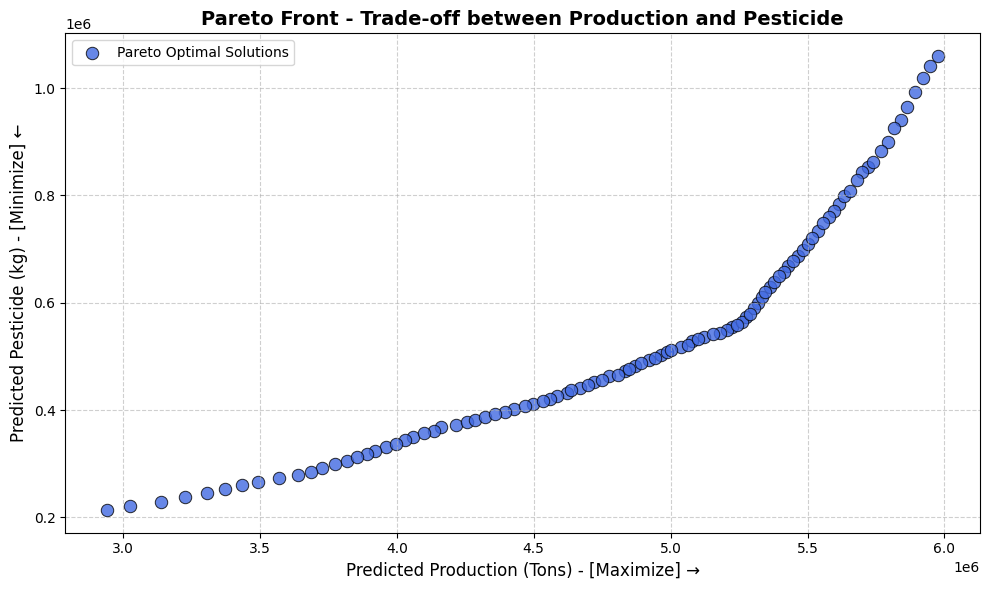

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=pareto_df['Predicted_Production'],
    y=pareto_df['Predicted_Pesticide'],
    color='royalblue',
    edgecolor='black',
    s=80,
    alpha=0.8,
    label='Pareto Optimal Solutions'
)


# Formatting the plot for your presentation
plt.title('Pareto Front - Trade-off between Production and Pesticide', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Production (Tons) - [Maximize] →', fontsize=12)
plt.ylabel('Predicted Pesticide (kg) - [Minimize] ←', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()